In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [2]:
df = pd.read_csv("../data/energy_data.csv")

df.columns = df.columns.str.strip()
df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])
df.set_index(df.columns[0], inplace=True)

# Create numeric time index
df['time_index'] = np.arange(len(df))

df.head()

,fridge,ac,lights,microwave,total_power,time_index
timestamp,,,,,,
2023-01-01 00:00:00,119,0,73,0,192,0
2023-01-01 01:00:00,134,0,0,0,134,1
2023-01-01 02:00:00,0,1551,73,0,1624,2
2023-01-01 03:00:00,0,0,66,0,66,3
2023-01-01 04:00:00,83,0,86,0,169,4


In [3]:
X = df[['time_index']]
y = df['total_power']

In [4]:
poly1 = PolynomialFeatures(degree=1)
X1 = poly1.fit_transform(X)

model1 = LinearRegression()
model1.fit(X1, y)

y_pred1 = model1.predict(X1)

print("Degree 1 R2:", r2_score(y, y_pred1))
print("Degree 1 MSE:", mean_squared_error(y, y_pred1))

Degree 1 R2: 0.29788198315485837
Degree 1 MSE: 667837.7932093979


In [5]:
poly2 = PolynomialFeatures(degree=2)
X2 = poly2.fit_transform(X)

model2 = LinearRegression()
model2.fit(X2, y)

y_pred2 = model2.predict(X2)

print("Degree 2 R2:", r2_score(y, y_pred2))
print("Degree 2 MSE:", mean_squared_error(y, y_pred2))

Degree 2 R2: 0.297894825248904
Degree 2 MSE: 667825.5781180004


In [6]:
poly3 = PolynomialFeatures(degree=3)
X3 = poly3.fit_transform(X)

model3 = LinearRegression()
model3.fit(X3, y)

y_pred3 = model3.predict(X3)

print("Degree 3 R2:", r2_score(y, y_pred3))
print("Degree 3 MSE:", mean_squared_error(y, y_pred3))

Degree 3 R2: 0.34829266574103046
Degree 3 MSE: 619888.3627649233


In [7]:
results = pd.DataFrame({
    "Degree": [1, 2, 3],
    "R2 Score": [
        r2_score(y, y_pred1),
        r2_score(y, y_pred2),
        r2_score(y, y_pred3)
    ],
    "MSE": [
        mean_squared_error(y, y_pred1),
        mean_squared_error(y, y_pred2),
        mean_squared_error(y, y_pred3)
    ]
})

results

,Degree,R2 Score,MSE
0,1,0.297882,667837.793209
1,2,0.297895,667825.578118
2,3,0.348293,619888.362765


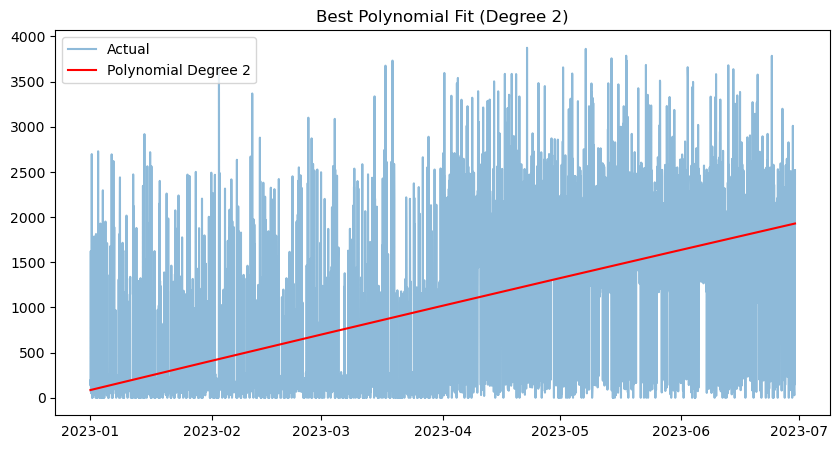

In [8]:
plt.figure(figsize=(10,5))
plt.plot(df.index, y, label="Actual", alpha=0.5)
plt.plot(df.index, y_pred2, label="Polynomial Degree 2", color='red')
plt.legend()
plt.title("Best Polynomial Fit (Degree 2)")
plt.show()

In [9]:
print("Degree 2 Coefficients:")
print(model2.coef_)

Degree 2 Coefficients:
[ 0.00000000e+00  4.37584902e-01 -2.51140144e-06]


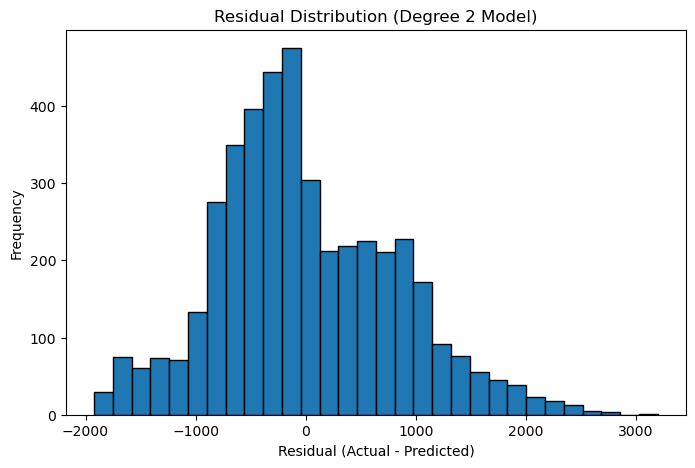

Residual Mean: 4.04126319695446e-14
Residual Std Dev: 817.3005367502186


In [10]:
residuals = y - y_pred2

plt.figure(figsize=(8,5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residual Distribution (Degree 2 Model)")
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.show()

print("Residual Mean:", residuals.mean())
print("Residual Std Dev:", residuals.std())

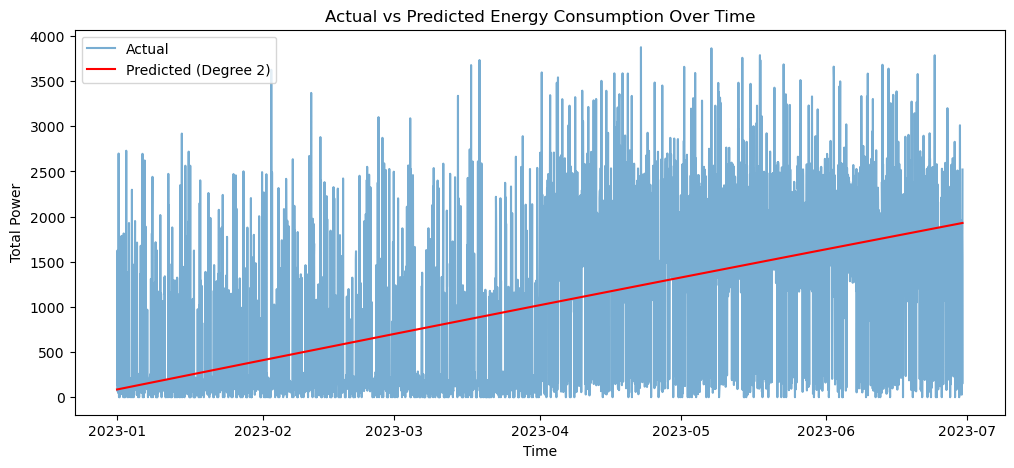

In [11]:
plt.figure(figsize=(12,5))
plt.plot(df.index, y, label="Actual", alpha=0.6)
plt.plot(df.index, y_pred2, label="Predicted (Degree 2)", color='red')
plt.title("Actual vs Predicted Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Total Power")
plt.legend()
plt.show()

In [12]:
print("Final Selected Model: Polynomial Degree 2")
print("R2 Score:", r2_score(y, y_pred2))
print("RMSE:", np.sqrt(mean_squared_error(y, y_pred2)))

Final Selected Model: Polynomial Degree 2
R2 Score: 0.297894825248904
RMSE: 817.2059582002571


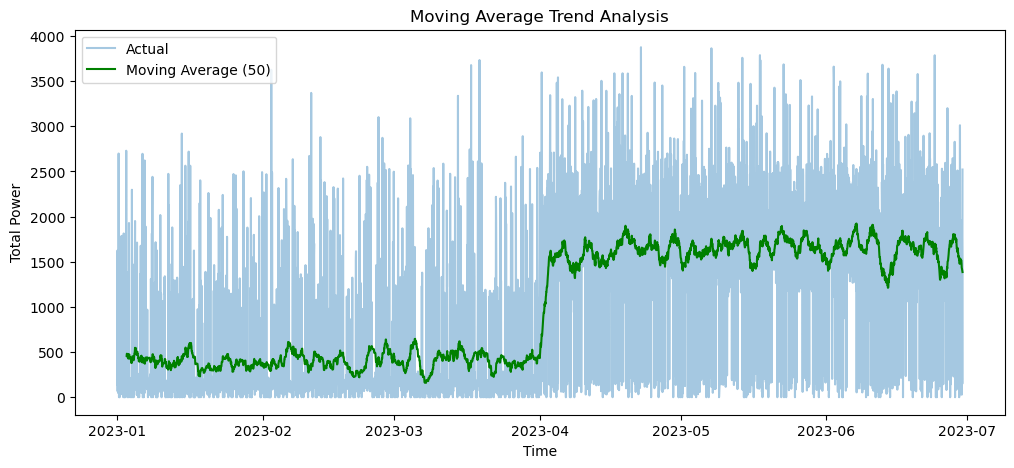

In [13]:
rolling_mean = y.rolling(window=50).mean()

plt.figure(figsize=(12,5))
plt.plot(df.index, y, label="Actual", alpha=0.4)
plt.plot(df.index, rolling_mean, label="Moving Average (50)", color='green')
plt.title("Moving Average Trend Analysis")
plt.xlabel("Time")
plt.ylabel("Total Power")
plt.legend()
plt.show()

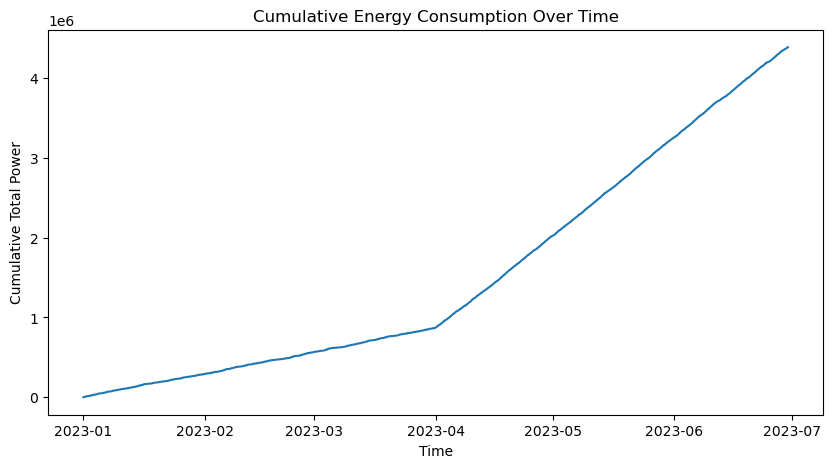

In [14]:
cumulative_energy = y.cumsum()

plt.figure(figsize=(10,5))
plt.plot(df.index, cumulative_energy)
plt.title("Cumulative Energy Consumption Over Time")
plt.xlabel("Time")
plt.ylabel("Cumulative Total Power")
plt.show()